# Scientific computing with Julia
#### Author - Job Feldbrugge

This tutorial serves as a first introduction into scientific computing with Julia. Rather than providing an in depth understanding of the Julia programming language, this workshop is aimed at introducing you to elementary examples of scientific computing to help you get started.

**Parts 5, 6, and 7 will be marked as the first part of Homework 5. They are due on GitHub by 12pm on Friday, 3 April.**

| <p align='left'> Part                | <p align='left'> Marks possible |  <p align='left'> Marks awarded |
| ------------------------------------- | --- | --- |
| <p align='left'> 1. Create a struct  | <p align='left'> -- | -- |
| <p align='left'> 2. Create a function  | <p align='left'> -- | -- |
| <p align='left'> 3. For loops | <p align='left'> -- | -- |
| <p align='left'> 4. Integration | <p align='left'> -- | -- |
| <p align='left'> 5. Parallelization  | <p align='left'> 2 |  |
| <p align='left'> 6. Polynomials  | <p align='left'> 1 |  |
| <p align='left'> 7. Forward differentiation  | <p align='left'> 2 |  |
| <p align='left'> 8. Homotopy continuation  | <p align='left'> -- | -- |
| <p align='left'> **Total** | <p align='left'> max **5** | |

## Part 1: Create a struct 

In Julia, you commonly use pre-developed data types. A variable can be an integer, a floating point number, a complex number a matrix or an array. In practice, it is very common to build your own composite types, wrapping relevant variables into a `struct` object (a class in Python). Read up on the use of composite types using the documentation https://docs.julialang.org/en/v1/manual/types/#Composite-Types and https://docs.julialang.org/en/v1/manual/types/#Mutable-Composite-Types.

Write a `struct Point` representing a point in the two-dimensional plane $\mathbb{R}^2$. 

In [1]:
struct Point
    xcoord::Float64
    ycoord::Float64
end

Initialize an instance of the `struct Point`  at position $(2, 3)$ and read out its attributes.

In [2]:
point = Point(2,3)

Point(2.0, 3.0)

 Try to change the $x$ component of the point. What goes wrong? Fix this issue. 

In [5]:
mutable struct mPoint
    xcoord::Float64
    ycoord::Float64
end

point = mPoint(2,3)
point.xcoord = 4
point

mPoint(4.0, 3.0)

## Part 2: Create a function

Julia is a function-oriented language. Place all your calculations in functions to make Julia compile and optimize them for you. Read up on how to define a function in the documentation https://docs.julialang.org/en/v1/manual/functions/

 Write a function that takes two `mutable struct Point` objects and outputs their sum. Evaluate the function on two points.

In [7]:
function sum(p::mPoint,q::mPoint)
    return mPoint(p.xcoord + q.xcoord, p.ycoord + q.ycoord)
end

qoint = mPoint(7,12)

sum(point,qoint)


mPoint(11.0, 15.0)

## Part 3: For loops

Read up on how to write a `for` loop in the documentation https://docs.julialang.org/en/v1/manual/control-flow/#man-loops

Write a for loop that translates the origin $p = (0,0)$ $5$ times by a unit step in the $y$ direction $\Delta = (0,1)$ with the function developed in question 5.

In [9]:
p = mPoint(0,0)
yshift = mPoint(0,1)
for i = 1:5
    p = sum(p,yshift)
end

p

mPoint(0.0, 5.0)

## Part 4: Integration

In practice, one often wants to integrate functions. A common method is known as Gaussian Quadrature, where the integral over the domain $[-1,1]$ is approximated by a sum over the function value in a strategically chosen set of points $x_i$ weighted by a set of weights $\omega_i$.

$$\int_{-1}^{1} f(x)\mathrm{d}x \approx \sum_{i=1}^N \omega_i f(x_i)$$

Read up on the documenting of the FastGaussQuadrature.jl library at https://juliaapproximation.github.io/FastGaussQuadrature.jl/stable/

Use FastGaussQuadrature.jl to approximate the integral $\int_{-1}^1 (x^2 - 2 x^4) \mathrm{d}x$ with Gauss-Legendre Quadratures. To what order $N$ do you need to go for an accurate answer?

In [11]:
import Pkg
Pkg.add("FastGaussQuadrature")

using FastGaussQuadrature, LinearAlgebra
x, w = gausslegendre(3)
f(x) = (x^2-2x^4)
I = dot(w,f.(x))

I ≈ -2/15

    Updating registry at `C:\Users\3010295H\.julia\registries\General.toml`
   Resolving package versions...
   Installed StaticArraysCore ──── v1.4.4
   Installed OpenSpecFun_jll ───── v0.5.6+0
   Installed IrrationalConstants ─ v0.2.6
   Installed LogExpFunctions ───── v0.3.29
   Installed FastGaussQuadrature ─ v1.1.0
   Installed SpecialFunctions ──── v2.7.1
   Installed DocStringExtensions ─ v0.9.5
   Installed StaticArrays ──────── v1.9.18
  Installing 1 artifacts
   Installed artifact OpenSpecFun 263.5 KiB
    Updating `C:\Users\3010295H\.julia\environments\v1.12\Project.toml`
  [442a2c76] + FastGaussQuadrature v1.1.0
    Updating `C:\Users\3010295H\.julia\environments\v1.12\Manifest.toml`
  [ffbed154] + DocStringExtensions v0.9.5
  [442a2c76] + FastGaussQuadrature v1.1.0
  [92d709cd] + IrrationalConstants v0.2.6
  [2ab3a3ac] + LogExpFunctions v0.3.29
  [276daf66] + SpecialFunctions v2.7.1
  [90137ffa] + StaticArrays v1.9.18
  [1e83bf80] + StaticArraysCore v1.4.4
  [efe28fd5] + O

true

Bonus question: Why is Gaussian quadratures so efficient? For what kind of functions should it be used? Have a look at https://en.wikipedia.org/wiki/Gaussian_quadrature

## Part 5: Parallelization

When evaluating a function multiple times with different arguments, it is often useful to perform the calculation in parallel. Have a look at the documentation https://docs.julialang.org/en/v1/manual/parallel-computing/ and https://docs.julialang.org/en/v1/manual/multi-threading/#man-multithreading

Implement the integral $I(a) = \int_{-1}^1 \cos (a x) \mathrm{d}x = \frac{2 \sin a}{a}$ in the domain $a\in [-10,10]$ using FastGaussQuadrature.jl in parallel.
Let $a$ vary over the domain in steps of size $0.1$.
Use the ```Threads.@threads``` command, from the library ```Base.Threads```. (You don't need to restart Julia with multiple threads; just implement a "data race").

In [38]:
as = range(-10,10,step=0.1)
Is = zeros(201)

x, w = gausslegendre(7)

Threads.@threads for i in 1:201
    f(x) = cos(as[i] * x)
    Is[i] = dot(w,f.(x))    
end

 Plot the result, using the Plots.jl library https://docs.juliaplots.org/stable/
To what order $N$ do we need the Gauss-Legendre Quadrature method for reasonable convergence? Ans: N=7 is good except at the very edges; N=8 is good throughout.

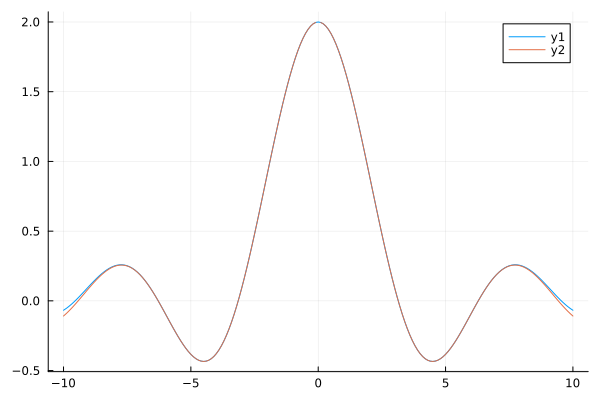

In [39]:
using Plots
g(x) = 2*sin(x)/x
plot(as,[Is g.(as)])

## Part 6: Polynomials

When you know what kind of function you are working with, many optimalizations are possible. We here consider the frequently used polynomial functions using Polynomials.jl  https://juliamath.github.io/Polynomials.jl/stable/

Define the function $f(x) = x^2 - 2 x^4$ and evaluate its derivative, antiderivative and roots.

In [44]:
using Polynomials
p = Polynomial([0,0,1,0,-2])

println(derivative(p))
println(integrate(p))
println(roots(p))

2*x - 8*x^3
0.333333*x^3 - 0.4*x^5
[-0.7071067811865476, 0.7071067811865475, 0.0, 0.0]


## Part 7: Differentiate a function with forward automatic differentiation

Study the documentation of ForwardDiff.jl on automatic forward differentiation https://juliadiff.org/ForwardDiff.jl/stable/

Use the automatic forward differentiation method from FowardDiff.jl to differentiate $f(x) = \cos x$ in the point $x=\pi/2$. 

In [46]:
using ForwardDiff

ForwardDiff.derivative(cos,pi/2)

-1.0

Compare the result with the first order finite-difference derivative $f'(x) = \frac{f(x+ \delta) - f(x- \delta) }{2 \delta}$ as a function of $\delta$ as we approach the limit $\delta \to 0$. E.g. consider $\delta = 2^{-n}$ for $n=1,2,3,...$.

 For how small a $\delta$ does the finite difference method start to fail?

In [54]:
for n = 1:60
    println(n,": ",(cos(pi /2 + 2. ^(-n)) - cos(pi/2 - 2. ^(-n)) )/(2*2. ^(-n)) )
end

1: -0.958851077208406
2: -0.9896158370180917
3: -0.9973978670818215
4: -0.9993490854780832
5: -0.9998372475304345
6: -0.9999593103925358
7: -0.9999898275050023
8: -0.9999974568704298
9: -0.9999993642172437
10: -0.9999998410542882
11: -0.9999999602635705
12: -0.9999999900658926
13: -0.9999999975164732
14: -0.9999999993791182
15: -0.9999999998447795
16: -0.9999999999611948
17: -0.9999999999902986
18: -0.9999999999975747
19: -0.9999999999993936
20: -0.9999999999998485
21: -0.999999999999962
22: -0.9999999999999906
23: -0.9999999999999977
24: -0.9999999999999993
25: -0.9999999999999998
26: -1.0
27: -1.0
28: -1.0
29: -1.0
30: -1.0
31: -1.0
32: -1.0
33: -1.0
34: -1.0
35: -1.0
36: -1.0
37: -1.0
38: -1.0
39: -1.0
40: -1.0
41: -1.0
42: -1.0
43: -1.0
44: -1.0
45: -1.0
46: -1.0
47: -1.0
48: -1.0
49: -1.0
50: -1.0
51: -1.0
52: -1.0
53: 0.0
54: 0.0
55: 0.0
56: 0.0
57: 0.0
58: 0.0
59: 0.0
60: 0.0


## Part 8: Homotopy Continuation

In algebraic geometry we consider the zero set of multivariate polynomials. These zero sets can be numerically evaluated using Homotopy Continuation, where topology meets scientific computing. Read the documentation and go through a couple examples of HomotopyContinuation.jl on the sites https://www.juliahomotopycontinuation.org/ and https://www.juliahomotopycontinuation.org/guides/introduction/

Find the zero set $V(f_1,f_2)$ of the polynomials 

$$ f_1(x,y) = y^2 - x^3 + x$$
$$ f_2(x,y) =  x - y$$

representing the intersection of a line and an elliptic curve.

# Bonus: Useful packages

To aid your work flow, the packages 

* Alert.jl (https://github.com/haberdashPI/Alert.jl), 
* ProgressMeter.jl (https://github.com/timholy/ProgressMeter.jl)
* Revise.jl (https://timholy.github.io/Revise.jl/stable/)

are very useful.

* Alert.jl notifies you when your current job finishes.
* ProgressMeter.jl generates a progress bar for loops
* Revise.jl keeps defined functions up to date when using multiple files

In [1]:
using Alert
alert("Done")

Process(`osascript -e 'display notification "Done" with title "Julia"'`, ProcessExited(0))

In [5]:
using ProgressMeter

@showprogress for i in 1:50
    sleep(0.1)
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:05
